# 3. The habitable-zone model

The Kopparapu et al. (2013) flux-boundary model, the corrected-vs-original
coefficient trap this project verified directly from the publisher PDF, and
the TRAPPIST-1 stellar-temperature edge case that turns out to matter a
great deal for the final ranking.


This notebook is part of the reproducibility set for **Finding Earth 2.0 in
Distant Worlds**. It reads the same committed data every other output in this
project reads (`results/`, `data/processed/`, `data/manifests/`) and calls
the same `earth2` functions the pipeline itself calls -- nothing here is a
simplified restatement computed a different way. Run `python -m earth2 all`
first if `results/` does not exist yet.

See `docs/METHODS.md` for the full equations and `docs/LIMITATIONS.md` for
this project's stated caveats.


In [1]:
import sys
sys.path.insert(0, "../src")

import numpy as np
import matplotlib.pyplot as plt

from earth2.habitability import hz

print("Validity range:", hz.HZ_TEFF_MIN, "-", hz.HZ_TEFF_MAX, "K")
print("Boundaries:", hz.BOUNDARIES)


Validity range: 2600.0 - 7200.0 K
Boundaries: ('recent_venus', 'runaway_greenhouse', 'moist_greenhouse', 'maximum_greenhouse', 'early_mars')


## The erratum trap

The arXiv v1 preprint of Kopparapu et al. (2013) -- the copy most easily
found by search -- carries only the original, superseded coefficient table.
The version of record (IOPscience) contains both the original and a June
2013 erratum. This project defaults to the erratum and keeps both, so the
correction's effect is measurable rather than silently applied.


In [2]:
teff_sun = 5772.0
for boundary in hz.BOUNDARIES:
    orig = float(hz.seff_boundary(teff_sun, boundary, hz.COEFFS_ORIGINAL_2013))
    err = float(hz.seff_boundary(teff_sun, boundary, hz.COEFFS_ERRATUM_2013))
    pct = 100 * (err - orig) / orig
    print(f"{boundary:22s}  original={orig:.4f}  erratum={err:.4f}  ({pct:+.2f}%)")


recent_venus            original=1.7742  erratum=1.7752  (+0.06%)
runaway_greenhouse      original=1.0501  erratum=1.0375  (-1.20%)
moist_greenhouse        original=1.0133  erratum=1.0139  (+0.06%)
maximum_greenhouse      original=0.3433  erratum=0.3502  (+2.01%)
early_mars              original=0.3175  erratum=0.3203  (+0.88%)


## Solar System controls through the model

Earth should sit just inside the runaway-greenhouse boundary (S_eff = 1 by
definition of the incident-flux unit); Venus should sit outside the recent-
Venus boundary; Mars should sit near the outer edge.


In [3]:
controls = {"Earth": (1.0, 5772.0), "Venus": (1.911, 5772.0), "Mars": (0.431, 5772.0)}
for name, (insol, teff) in controls.items():
    m = hz.hz_membership(insol, teff)
    print(f"{name:8s}  insolation={insol:.3f} S_earth  "
          f"conservative={bool(m['hz_conservative'])}  optimistic={bool(m['hz_optimistic'])}")


Earth     insolation=1.000 S_earth  conservative=True  optimistic=True
Venus     insolation=1.911 S_earth  conservative=False  optimistic=False
Mars      insolation=0.431 S_earth  conservative=True  optimistic=True


## The flux-temperature diagram

Every confirmed planet placed by incident flux and host effective
temperature, with the five Kopparapu boundaries drawn as curves in
temperature. This is the same figure published as
`results/figures/hz_diagram.png`; reproduced here from the underlying
function calls rather than loaded as an image.


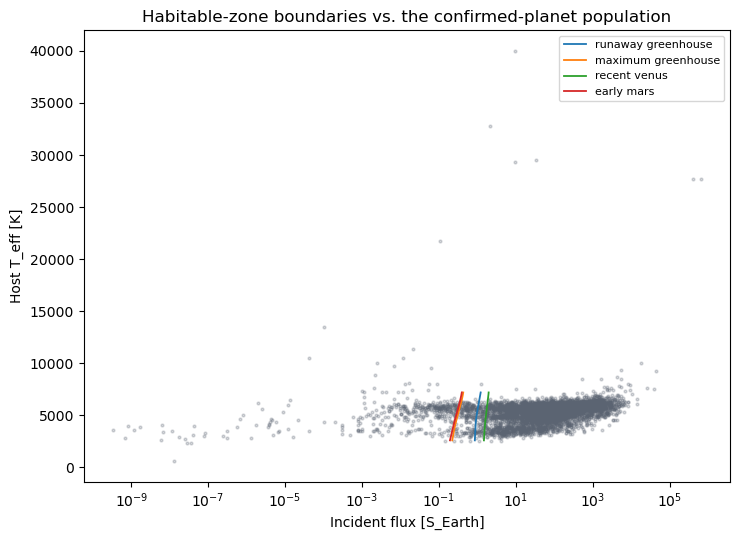

In [4]:
import pandas as pd
from earth2.config import RESULTS_DIR

cat = pd.read_parquet(RESULTS_DIR / "candidate_ranking.parquet")
planets = cat[~cat["is_control"].fillna(False)]

teff_grid = np.linspace(hz.HZ_TEFF_MIN, hz.HZ_TEFF_MAX, 200)
fig, ax = plt.subplots(figsize=(7.5, 5.5))
for b in ("runaway_greenhouse", "maximum_greenhouse", "recent_venus", "early_mars"):
    ax.plot(hz.seff_boundary(teff_grid, b), teff_grid, lw=1.3, label=b.replace("_", " "))

ok = planets["insol_used"].notna() & planets["st_teff"].notna()
ax.scatter(planets.loc[ok, "insol_used"], planets.loc[ok, "st_teff"],
           s=4, alpha=0.25, color="#5b6472", zorder=1)
ax.set_xscale("log")
ax.set_xlabel("Incident flux [S_Earth]"); ax.set_ylabel("Host T_eff [K]")
ax.legend(fontsize=8); ax.set_title("Habitable-zone boundaries vs. the confirmed-planet population")
plt.tight_layout(); plt.show()


## Why TRAPPIST-1 is not a simple yes/no

TRAPPIST-1's host is 2,566 K -- 34 K below the model's stated validity floor.
The fit still *returns a number* there; it does not raise an error. This
project reports both a strict reading (undetermined outside the fit's
domain) and a flagged extrapolation, and -- critically -- discounts the
ranking's habitability score by how much of the Monte Carlo posterior
actually fell inside the valid range (Notebook 6).


In [5]:
trappist_teff = 2566.0
print("Inside stated validity range:", hz.HZ_TEFF_MIN <= trappist_teff <= hz.HZ_TEFF_MAX)
print("Offset below floor:", hz.HZ_TEFF_MIN - trappist_teff, "K")
# The fit still returns a value when clipped -- this is the trap the module exists to guard against.
clamped = float(hz.seff_boundary(trappist_teff, "runaway_greenhouse", clip_to_validity=True))
print("Clamped-extrapolation S_eff (flagged, not a supported evaluation):", round(clamped, 4))


Inside stated validity range: False
Offset below floor: 34.0 K
Clamped-extrapolation S_eff (flagged, not a supported evaluation): 0.8566
